 **Problema 3: Integración mediante PINNs**

Elija un flujo del Problema 1 o del Problema 2. Compararemos las trayectorias obtenidas (sea analítica o numéricamente) con lo obtenido mediante el uso de Redes Neuronales Informadas por la Física (PINNs, vease apunte).
Limitese a una única trayectoria, dada por un único punto inicial $(x_0, y_0)$ y un dado conjunto de parámetros adimensionales (si elige un flujo del Problema 1, antes adimensionalícelo).
Elija un tiempo de integración $T$ tal que la dinámica es rica (puede ser el mismo que usó para integrar numéricamente).
En la celda a continuación le proporcionamos la estructura general de la PINN.

(i) Provea a la red con $10$ puntos de entrenamiento de datos, $20$ puntos de entrenamiento de física y $\lambda = 10^{-4}$, ambos equiespaciados en $[0, T]$ (asegúrese de incluir tanto $0$ cómo $T$), y entrénela durante $20000$ épocas. Grafique tanto el error de los datos cómo el de la física en función de la época para determinar. Interprete. ¿Cuantas épocas considera suficientes?

(ii) Utilice la red entrenada (con $20000$ épocas) para calcular la trayectoria más allá de $T$ y calcule el error $\epsilon(t) = |\mathbf{X}_\mathrm{PINN}(t) - \mathbf{X}(t)|$. Grafiquelo e interprete. ¿Hasta que valor de $t$ considera adecuada la red? ¿Puede identificar los tiempos donde $\mathbf{X}(t)$ corresponde a un punto de entrenamiento y/o de física? Repita esto para un entrenamiento con puntos de entrenamiento de física uniformemente distribuidos en $[0, 2T]$, **sin cambiar la cantidad**. ¿Mejora la aproximación? Interprete.

(iii) Manteniendo los $20$ puntos de entrenamiento de física, varíe la cantidad de puntos de entrenamiento de datos $N_d$ entre $2$ y $20$ y grafique el error medio $\epsilon_M = \sum_n \epsilon(t_n)$ para cada $N_d$. Interprete la ganancia de precisión teniendo en cuenta el tiempo de entrenamiento necesario. ¿Cambia la cantidad de épocas óptima para cada $N_d$?

(iv) Repita el inciso anterior pero manteniendo $N_d = 10$ puntos de entrenamiento de datos y varíe la cantidad de puntos de entrenamiento de física $N_f$ entre $5$ y $50$.

(v) Fijando $N_d=10$ y $N_f=20$, varie $\lambda$ logarítmicamente entre $10^{-6}$ y $10^{-1}$ y compare ambas funciones de pérdida y $\epsilon_M$ para cada caso.

(vi) (Opcional) Fijando $N_d$, $N_f$ y $\lambda$ a gusto, pruebe distintas arquitecturas para la red y compare sus desempeños. ¿Considera alguna óptima? _Ayuda: Por cuestiones de desempeño, evite redes con más de 3 capas ocultas._


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

Antes de iniciar sobre los problemas, definimos los métodos a utilizar en los distintos ítems, así como también la PINN que se empleará.

En este caso, consideramos el problema $2_{(i)}$ en su forma adimensional, el cual describe un campo de velocidades bidimensional dependiente del tiempo, donde el campo de velocidades está dado por la superposición de una fuente puntual y una corriente uniforme dependiente del tiempo.

$\frac{d\mathbf{X}}{dt} = \mathbf{u}(\mathbf{X},t),
\qquad \mathbf{X}(t) = (x(t),y(t)),$

donde, en forma explícita, el campo de velocidades adimensional viene dado por:

$\mathbf{u}(\mathbf{X},t) =
\left(
\frac{x}{x^2 + y^2} + t,\;
\frac{y}{x^2 + y^2}
\right).$

Tal como vimos anteriormente este sistema no admite una solución analítica cerrada, por lo que para no repetir analisis recurriremos a un método numérico para obtener trayectorias de referencia. En particular, se implementa un esquema de Runge-Kutta de cuarto orden, el cual permite aproximar con alta precisión la evolución temporal de las partículas en el flujo. De este modo, las trayectorias obtenidas mediante RK4 se utilizan como “datos reales” para el entrenamiento de la PINN.

Para este problema la dinámica está gobernada por un campo de velocidades bidimensional dependiente de la posición y del tiempo. En particular, la presencia de términos del tipo $\frac{x}{x^2 + y^2},  \frac{y}{x^2 + y^2}$ introducen una singularidad en el origen, ya que cuando $r^2 = x^2 + y^2 \to 0$ se tiene una divergencia del campo.

Esto genera gradientes muy grandes en las cercanías del origen, lo cual puede producir inestabilidades tanto en la integración numérica de referencia como en el cálculo del residuo físico dentro de la PINN.

Para evitar este comportamiento, se introduce un parámetro de regularización $\epsilon$, reemplazando $r^2 \to r^2 + \epsilon^2$, lo que suaviza el campo de velocidades sin alterar significativamente su estructura global.


In [ ]:
# ====================== FUNCIÓN DE LA EDO ======================

def f_vec(t, X):
    x, y = X
    r2 = x**2 + y**2
    eps = 0.05 #esto es para que no explote cuando r2=0
    denom = r2 + eps**2

    ux = x/denom + t
    uy = y/denom

    return np.array([ux, uy])

def f_vec_torch(t, X):
    x = X[:,0:1]
    y = X[:,1:2]

    r2 = x**2 + y**2
    eps = 0.05  #esto es para que no explote cuando r2=0
    denom = r2 + eps**2

    ux = x/denom + t
    uy = y/denom

    return torch.cat([ux, uy], dim=1)

def rk4_vec(f, t0, X0, T, N):
    dt = T / N
    t = np.zeros(N+1)
    X = np.zeros((N+1, 2))

    t[0] = t0
    X[0] = X0

    for i in range(N):
        ti = t[i]
        Xi = X[i]

        k1 = f(ti, Xi)
        k2 = f(ti + dt/2, Xi + dt*k1/2)
        k3 = f(ti + dt/2, Xi + dt*k2/2)
        k4 = f(ti + dt, Xi + dt*k3)

        X[i+1] = Xi + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        t[i+1] = ti + dt

    return t, X

Luego definimos en una clase la PINN a utilizar, con todos los elementos necesarios para su uso inmediato en los items.
La PINN se implementa como una red neuronal en $\texttt{PyTorch}$ que aproxima la trayectoria del sistema $\mathbf{X}(t)$.
La arquitectura recibe como entrada un parámetro escalar (tiempo) y devuelve una salida vectorial bidimensional. Del mismo modo, se utilizan varias capas ocultas (modificables en los parámetros de inicialización de la clase) junto con la función de activación $\tanh$, de manera que la salida esperada es:
$t \;\longrightarrow\; \mathbf{X}_{\theta}(t) = (x_{\theta}(t),y_{\theta}(t)),$ donde $\theta$ representa los parámetros entrenables de la red.

La función $\texttt{forward}$ evalúa la red propagando la entrada a través de capas lineales y aplicando $\tanh$ en cada capa intermedia, obteniendo simultáneamente ambas componentes de la trayectoria.

El entrenamiento se basa en la minimización de una función de pérdida total definida como:
$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda\,\mathcal{L}_{\text{phys}}$
donde el término de datos ($\texttt{data\_loss}$) corresponde al error cuadrático medio entre la predicción de la red y los valores de referencia:
$\mathcal{L}_{\text{data}} = \left\langle \left\|\mathbf{X}_{\theta}(t) - \mathbf{X}_{\text{data}}\right\|^2 \right\rangle.$
Por otro lado, el término físico ($\texttt{physics\_loss}$) impone la ecuación diferencial mediante diferenciación automática. En particular, las derivadas temporales de cada componente se calculan utilizando $\texttt{autograd}$:
$\frac{d\mathbf{X}}{dt} \approx \texttt{autograd}(\mathbf{X}_{\theta}(t)).$
y se construye el residuo de la ecuación:
$\text{residual} = \frac{d\mathbf{X}}{dt} - \mathbf{u}(\mathbf{X},t),$
y el término físico penaliza el valor medio del cuadrado de su norma:
$\mathcal{L}_{\text{phys}} = \left\langle \left\| \frac{d\mathbf{X}}{dt} - \mathbf{u}(\mathbf{X},t) \right\|^2 \right\rangle.$
El entrenamiento se realiza mediante el optimizador Adam y la función $\texttt{.backward}$, iterando sobre puntos de datos y puntos físicos, y almacenando la evolución de las pérdidas para analizar la convergencia del modelo.

Finalmente, se define la función $\texttt{plot\_loss}$ para visualizar la evolución de las pérdidas durante el entrenamiento, facilitando el análisis del comportamiento de la red sin introducir código adicional innecesario.

In [ ]:

# ====================== CLASE PINN ======================
class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32, 32, 32]):
        super().__init__()
        layers = [1] + hidden_sizes + [2]
        self.layers = torch.nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(torch.nn.Linear(layers[i], layers[i+1]))

        self.loss_history = []
        self.loss_data_history = []
        self.loss_physics_history = []

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)  # (x,y)

    def data_loss(self, t_data, X_data):
        return torch.mean((self.forward(t_data) - X_data)**2)

    def physics_loss(self, t_physics, f_func):
        t_physics = t_physics.requires_grad_(True)

        X = self.forward(t_physics)
        x = X[:,0:1]
        y = X[:,1:2]

        dx_dt = torch.autograd.grad(x, t_physics, torch.ones_like(x), create_graph=True)[0]
        dy_dt = torch.autograd.grad(y, t_physics, torch.ones_like(y), create_graph=True)[0]

        dX_dt = torch.cat([dx_dt, dy_dt], dim=1)

        u = f_func(t_physics, X)

        residual = dX_dt - u
        return torch.mean(residual ** 2)

    def total_loss(self, t_data, X_data, t_physics, f_func, lambda_phys=1e-4):
        ld = self.data_loss(t_data, X_data)
        lp = self.physics_loss(t_physics, f_func)
        return ld + lambda_phys * lp, ld, lp

    def train_pinn(self, t_data, X_data, t_physics, f_func,
                   lambda_phys=1e-4, epochs=20000, lr=1e-4, print_every=2000):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss_total, ld, lp = self.total_loss(t_data, X_data, t_physics, f_func, lambda_phys)
            loss_total.backward()
            optimizer.step()

            self.loss_history.append(loss_total.item())
            self.loss_data_history.append(ld.item())
            self.loss_physics_history.append(lp.item())

            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d} | Total: {loss_total.item():.2e} | "
                      f"Data: {ld.item():.2e} | Physics: {lp.item():.2e}")
        print("Entrenamiento completado.\n")
        return self

    def plot_loss(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, label='Pérdida Total', linewidth=2)
        plt.plot(self.loss_data_history, label='Pérdida Datos', alpha=0.8)
        plt.plot(self.loss_physics_history, label='Pérdida Física', alpha=0.8)
        plt.yscale('log')
        plt.xlabel('Época')
        plt.ylabel('Pérdida')
        plt.title('Evolución de las pérdidas (PINN 2D)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()




##  Punto i)

Para este inciso se entrenó la PINN utilizando $10$ puntos de datos y $20$ puntos de física, ambos equiespaciados en el intervalo $[0,T]$, incluyendo los extremos.

Respecto del entrenamiento, el valor $\lambda = 10^{-4}$ implica que el ajuste a los datos tiene mayor peso relativo que el cumplimiento estricto de la ecuación diferencial. Esto se refleja en la evolución de las pérdidas: el error de datos decrece rápidamente en las primeras épocas, mientras que el error físico lo hace de forma más gradual.

A partir del análisis de los gráficos, se concluye que llegados a las 5000 epocas aproximadamente el error llega a un orden igual al provocado por RK4 (1e-5), por tanto esta cantida de epocas resultan suficientes para capturar la dinámica principal de la trayectoria

Epoch     0 | Total: 7.91e-01 | Data: 7.90e-01 | Physics: 9.61e+00
Epoch  2000 | Total: 5.39e-03 | Data: 5.38e-03 | Physics: 9.51e-02
Epoch  4000 | Total: 2.90e-04 | Data: 2.88e-04 | Physics: 1.91e-02
Epoch  6000 | Total: 5.99e-05 | Data: 5.93e-05 | Physics: 6.13e-03
Epoch  8000 | Total: 1.12e-05 | Data: 1.10e-05 | Physics: 1.92e-03
Epoch 10000 | Total: 2.56e-06 | Data: 2.47e-06 | Physics: 8.90e-04
Epoch 12000 | Total: 1.15e-06 | Data: 1.11e-06 | Physics: 4.91e-04
Epoch 14000 | Total: 8.18e-07 | Data: 7.89e-07 | Physics: 2.83e-04
Epoch 16000 | Total: 3.70e-07 | Data: 3.51e-07 | Physics: 1.90e-04
Epoch 18000 | Total: 2.86e-07 | Data: 2.71e-07 | Physics: 1.52e-04
Entrenamiento completado.



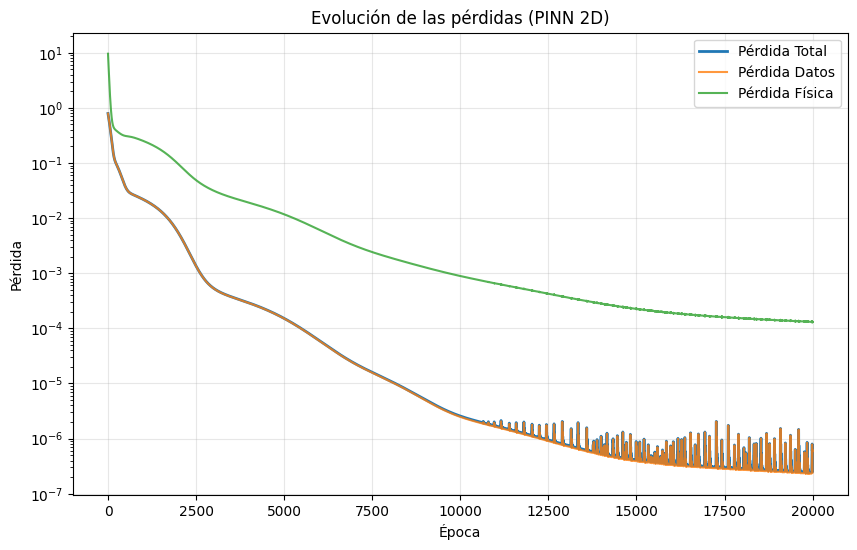

In [ ]:
# ====================== DATOS ======================
t0, T = 0.0, 2.0
X0 = np.array([-1.0, 0.5])

t_full, X_full = rk4_vec(f_vec, t0, X0, T, 1000)

# 10 puntos de datos
idx_data = np.linspace(0, len(t_full)-1, 10, dtype=int)
t_data = t_full[idx_data][:,None]
X_data = X_full[idx_data]

# 20 puntos de física
t_phys = np.linspace(t0, T, 20)[:,None]

# a torch
t_data = torch.tensor(t_data, dtype=torch.float32)
X_data = torch.tensor(X_data, dtype=torch.float32)
t_phys = torch.tensor(t_phys, dtype=torch.float32)

# ====================== ENTRENAMIENTO ======================
model = PINN()

model.train_pinn(
    t_data,
    X_data,
    t_phys,
    f_func=f_vec_torch,
    lambda_phys=1e-4,
    epochs=20000,
    lr=1e-4
)

# ====================== GRAFICO ======================
model.plot_loss()

Se compara la trayectoria obtenida mediante RK4 con la predicción de la PINN, observándose un buen acuerdo global.

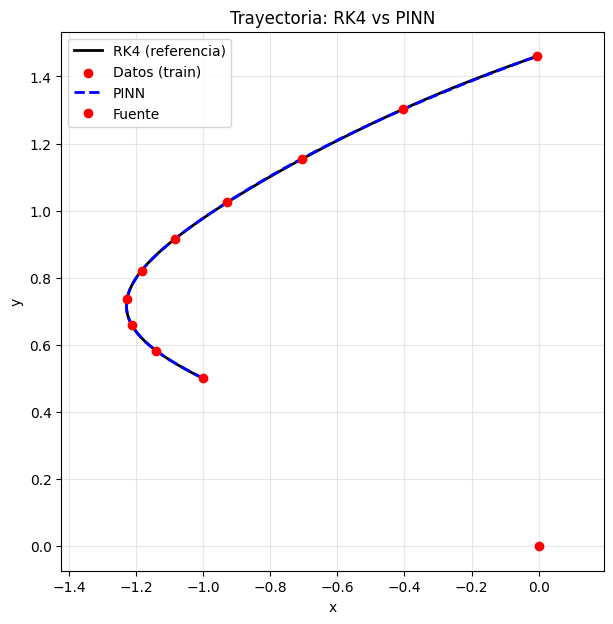

In [ ]:
# ====================== PREDICCION PINN ======================
with torch.no_grad():
    t_plot = torch.tensor(t_full[:,None], dtype=torch.float32)
    X_pred = model.forward(t_plot).numpy()

# ====================== GRAFICO ======================
plt.figure(figsize=(7,7))

# trayectoria real (RK4)
plt.plot(X_full[:,0], X_full[:,1], 'k-', label='RK4 (referencia)', linewidth=2)

# datos usados para entrenar
plt.scatter(X_data[:,0], X_data[:,1], c='red', label='Datos (train)', zorder=3)

# prediccion PINN
plt.plot(X_pred[:,0], X_pred[:,1], 'b--', label='PINN', linewidth=2)

# origen (singularidad)
plt.plot(0,0,'ro',label='Fuente')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectoria: RK4 vs PINN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.show()

## Punto ii)

Para este inciso se utilizó la red entrenada durante $20000$ épocas para extrapolar la trayectoria más allá del intervalo de entrenamiento $[0,T]$. Se definió el error como:

$\epsilon(t) = \left\| \mathbf{X}_{\mathrm{PINN}}(t) - \mathbf{X}(t) \right\|,$

donde $\mathbf{X}(t)$ corresponde a la solución de referencia obtenida mediante RK4.

Se observa que en el intervalo de entrenamiento $[0,T]$ el error se mantiene bajo, sin embargo, al extrapolar para $t > T$, el error crece progresivamente, esto da a entender que la PINN no es capaz de generalizar el problema mas alla del intervalo de entrenamiento utilizado, por lo tanto se concluye que la red resulta confiable aproximadamente hasta valores de $t \lesssim T$, mientras que para tiempos mayores la precisión se degrada de manera significativa.
En cuanto a los puntos donde X(t) corresponde a un punto de entreneamiento fisico, no son distinguibles a simple vista, esto puede deberse a un entrenamiento muy prolongado que minimiza suavemente los datos entrenados en contraste a los datos del simulador de RK4


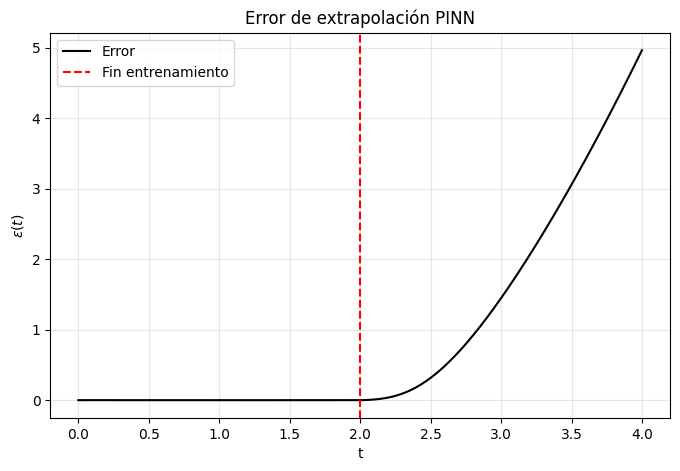

In [ ]:
# ====================== EXTENSION DEL DOMINIO ======================
T_ext = 2*T

t_ext, X_ext = rk4_vec(f_vec, t0, X0, T_ext, 2000)

# predicción PINN
with torch.no_grad():
    t_ext_torch = torch.tensor(t_ext[:,None], dtype=torch.float32)
    X_pred_ext = model.forward(t_ext_torch).numpy()

# ====================== ERROR ======================
error = np.linalg.norm(X_pred_ext - X_ext, axis=1)

# ====================== GRAFICO ======================
plt.figure(figsize=(8,5))
plt.plot(t_ext, error, 'k-', label='Error')
plt.axvline(T, color='r', linestyle='--', label='Fin entrenamiento')
plt.xlabel('t')
plt.ylabel(r'$\epsilon(t)$')
plt.title('Error de extrapolación PINN')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Al repetir el entrenamiento utilizando puntos de física uniformemente distribuidos en el intervalo $[0,2T]$, sin modificar su cantidad, se observa una mejora en la extrapolación. En particular, el crecimiento del error más allá de $T$ es más lento, lo que indica que la inclusión de información física en un dominio más amplio permite a la red capturar mejor la dinámica global del sistema.



Epoch     0 | Total: 7.52e-01 | Data: 7.51e-01 | Physics: 1.01e+01
Epoch  2000 | Total: 3.68e-03 | Data: 3.45e-03 | Physics: 2.31e+00
Epoch  4000 | Total: 4.31e-04 | Data: 2.11e-04 | Physics: 2.21e+00
Epoch  6000 | Total: 2.85e-04 | Data: 7.67e-05 | Physics: 2.08e+00
Epoch  8000 | Total: 2.13e-04 | Data: 1.65e-05 | Physics: 1.96e+00
Epoch 10000 | Total: 1.79e-04 | Data: 3.15e-06 | Physics: 1.76e+00
Epoch 12000 | Total: 1.40e-04 | Data: 1.40e-06 | Physics: 1.39e+00
Epoch 14000 | Total: 9.80e-05 | Data: 9.12e-07 | Physics: 9.71e-01
Epoch 16000 | Total: 6.08e-05 | Data: 9.10e-07 | Physics: 5.98e-01
Epoch 18000 | Total: 3.12e-05 | Data: 8.68e-07 | Physics: 3.03e-01
Entrenamiento completado.



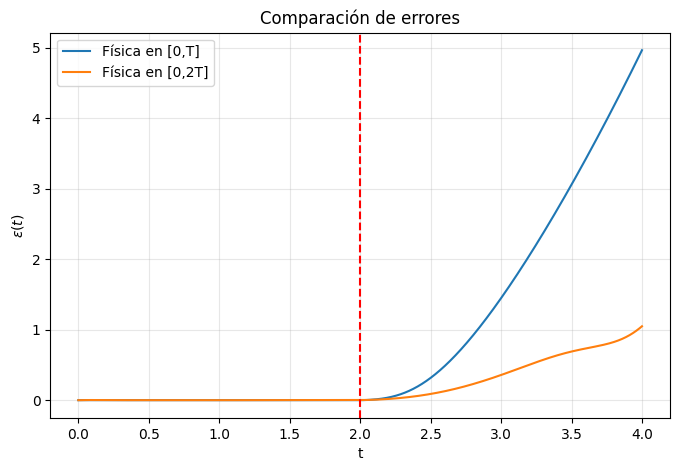

In [ ]:
# nuevos puntos físicos
t_phys_2T = torch.linspace(t0, 2*T, 20).reshape(-1,1)

model2 = PINN()

model2.train_pinn(
    t_data,
    X_data,
    t_phys_2T,
    f_func=f_vec_torch,
    lambda_phys=1e-4,
    epochs=20000,
    lr=1e-4
)

# predicción nueva
with torch.no_grad():
    X_pred_ext2 = model2.forward(t_ext_torch).numpy()

error2 = np.linalg.norm(X_pred_ext2 - X_ext, axis=1)

# comparación
plt.figure(figsize=(8,5))
plt.plot(t_ext, error, label='Física en [0,T]')
plt.plot(t_ext, error2, label='Física en [0,2T]')
plt.axvline(T, color='red', linestyle='--')
plt.xlabel('t')
plt.ylabel(r'$\epsilon(t)$')
plt.title('Comparación de errores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Punto iii)

En este inciso se analizó la dependencia del error medio de la PINN con la cantidad de puntos de entrenamiento de datos $N_d$, manteniendo fija la cantidad de puntos de entrenamiento de física en $20$.

Para cada valor de $N_d \in [2,20]$, se entrenó la red durante $20000$ épocas y se calculó el error medio definido como:

$\epsilon_M = \left\langle \epsilon(t_n) \right\rangle = \left\langle \left\| \mathbf{X}_{\mathrm{PINN}}(t_n) - \mathbf{X}(t_n) \right\| \right\rangle.$



In [ ]:
Nd_values = [2, 4, 6, 10, 15, 20]

loss_histories = {}
errors_mean = []

import time

for Nd in Nd_values:

    idx = np.linspace(0, len(t_full)-1, Nd, dtype=int)

    t_data = torch.tensor(t_full[idx][:,None], dtype=torch.float32)
    X_data = torch.tensor(X_full[idx], dtype=torch.float32)

    t_phys = torch.linspace(t0, T, 20).reshape(-1,1)

    model = PINN()

    start = time.time()

    model.train_pinn(
        t_data,
        X_data,
        t_phys,
        f_func=f_vec_torch,
        lambda_phys=1e-4,
        epochs=20000,
        lr=1e-4,
        print_every=20000
    )

    end = time.time()

    # guardar loss total
    loss_histories[Nd] = model.loss_history.copy()

    # error medio
    with torch.no_grad():
        t_eval = torch.tensor(t_full[:,None], dtype=torch.float32)
        X_pred = model.forward(t_eval).numpy()

    error = np.linalg.norm(X_pred - X_full, axis=1)
    errors_mean.append(np.mean(error))

    print(f"Nd={Nd} | error={errors_mean[-1]:.3e} | tiempo={end-start:.1f}s")

Epoch     0 | Total: 9.47e-01 | Data: 9.44e-01 | Physics: 2.27e+01
Entrenamiento completado.

Nd=2 | error=1.552e-02 | tiempo=34.9s
Epoch     0 | Total: 6.98e-01 | Data: 6.97e-01 | Physics: 1.06e+01
Entrenamiento completado.

Nd=4 | error=1.926e-02 | tiempo=30.6s
Epoch     0 | Total: 7.39e-01 | Data: 7.38e-01 | Physics: 9.82e+00
Entrenamiento completado.

Nd=6 | error=1.667e-03 | tiempo=31.0s
Epoch     0 | Total: 1.05e+00 | Data: 1.05e+00 | Physics: 2.43e+01
Entrenamiento completado.

Nd=10 | error=6.441e-04 | tiempo=29.9s
Epoch     0 | Total: 9.10e-01 | Data: 9.08e-01 | Physics: 2.17e+01
Entrenamiento completado.

Nd=15 | error=6.014e-04 | tiempo=30.5s
Epoch     0 | Total: 5.98e-01 | Data: 5.98e-01 | Physics: 1.91e+00
Entrenamiento completado.

Nd=20 | error=4.146e-04 | tiempo=29.2s


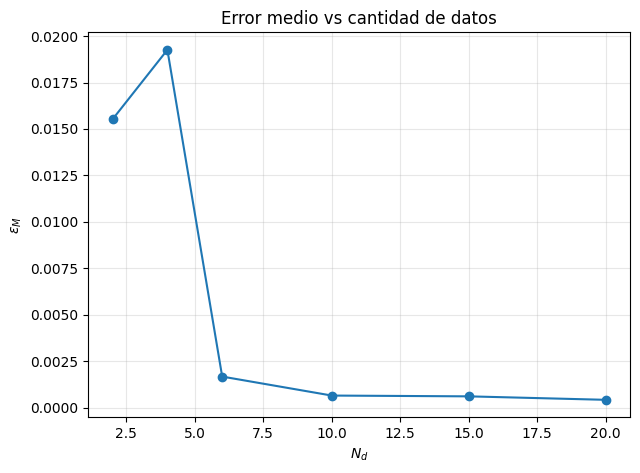

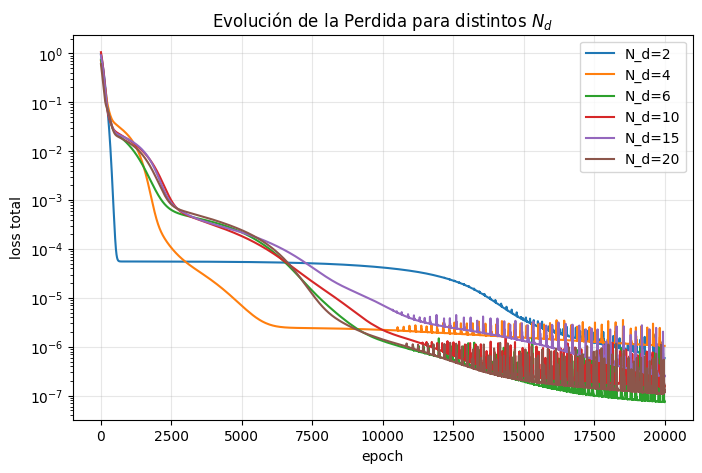

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(Nd_values, errors_mean, 'o-')
plt.xlabel(r'$N_d$')
plt.ylabel(r'$\epsilon_M$')
plt.title('Error medio vs cantidad de datos')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
for Nd in Nd_values:
    plt.plot(loss_histories[Nd], label=f'N_d={Nd}')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss total')
plt.title('Evolución de la Perdida para distintos $N_d$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Se observa que para los primeros valores pequeños de $N_d$ el error es elevado, lo que indica que la red no dispone de suficiente información para reconstruir adecuadamente la trayectoria. Sin embargo a medida que aumenta $N_d$, el error decrece de forma significativa, evidenciando una mejora en la capacidad de ajuste de la red

Adicionalmente, se analizó la evolución de la función de pérdida total para los distintos valores de $N_d$. Se observa que para $N_d = 2$ la convergencia se estanca lo que indica un claro problema de gradiente desvaneciente que impide que a red aprenda mas alla de estos parametros. Esto tiene sentido pues refleja la falta de informacion sobre los datos, y sugiere que aunque la estructura de la PINN sea la correcta si no se tienen datos suficientes para representar el fenomeno sera imposible recrearlo o modelarlo.

Respecto a la cantidad óptima de épocas, no se observan cambios significativos en el orden de magnitud requerido para la convergencia.

## Punto iv)

En este inciso se mantuvo fija la cantidad de puntos de entrenamiento de datos en $N_d = 10$, mientras que se varió la cantidad de puntos de entrenamiento de física $N_f$ en el rango $[5,50]$.

Para cada valor de $N_f$, se entrenó la red durante $20000$ épocas y se calculó el error medio:

$\epsilon_M = \left\langle \left\| \mathbf{X}_{\mathrm{PINN}}(t_n) - \mathbf{X}(t_n) \right\| \right\rangle.$




In [9]:
Nf_values = [5, 10, 20, 30, 50]

loss_histories_f = {}
errors_mean_f = []

Nd = 10  # fijo

# datos fijos
idx = np.linspace(0, len(t_full)-1, Nd, dtype=int)
t_data = torch.tensor(t_full[idx][:,None], dtype=torch.float32)
X_data = torch.tensor(X_full[idx], dtype=torch.float32)

for Nf in Nf_values:

    # puntos físicos variables
    t_phys = torch.linspace(t0, T, Nf).reshape(-1,1)

    model = PINN()

    model.train_pinn(
        t_data,
        X_data,
        t_phys,
        f_func=f_vec_torch,
        lambda_phys=1e-4,
        epochs=20000,
        lr=1e-4,
        print_every=20000
    )

    # guardar loss total
    loss_histories_f[Nf] = model.loss_history.copy()

    # error medio
    with torch.no_grad():
        t_eval = torch.tensor(t_full[:,None], dtype=torch.float32)
        X_pred = model.forward(t_eval).numpy()

    error = np.linalg.norm(X_pred - X_full, axis=1)
    errors_mean_f.append(np.mean(error))

    print(f"Nf={Nf} -> error medio = {errors_mean_f[-1]:.3e}")

Epoch     0 | Total: 7.82e-01 | Data: 7.80e-01 | Physics: 1.71e+01
Entrenamiento completado.

Nf=5 -> error medio = 5.426e-04
Epoch     0 | Total: 9.74e-01 | Data: 9.71e-01 | Physics: 3.01e+01
Entrenamiento completado.

Nf=10 -> error medio = 8.749e-04
Epoch     0 | Total: 7.91e-01 | Data: 7.88e-01 | Physics: 2.12e+01
Entrenamiento completado.

Nf=20 -> error medio = 7.655e-04
Epoch     0 | Total: 1.17e+00 | Data: 1.17e+00 | Physics: 1.87e+01
Entrenamiento completado.

Nf=30 -> error medio = 3.805e-04
Epoch     0 | Total: 7.04e-01 | Data: 7.03e-01 | Physics: 8.81e+00
Entrenamiento completado.

Nf=50 -> error medio = 5.915e-04


Se observa que para valores pequeños de $N_f$, el error es mas alto, lo que indica que la red no logra incorporar adecuadamente la estructura física del problema y tiende a comportarse como un interpolador de los datos.
Sin embargo estos cambios solo ocurren en las escalas del tercer decimal, por lo que globalmente no hay diferencias apreciables, esto es probablemente al termino lambda de la funcion de perdida pues, $\lambda =  1e-4$ es un valor extremadamente chico,
en general a la red no le importara demasiado el termino fisico a la hora de disminuir su error global, esto es interesante de ver en la evolucion de la funcion de perdida (global), pues esta no depende de la cantidad de los datos de entrenamiento fisico, sino que se comporta de igual manera independiente de la cantidad $N_f$

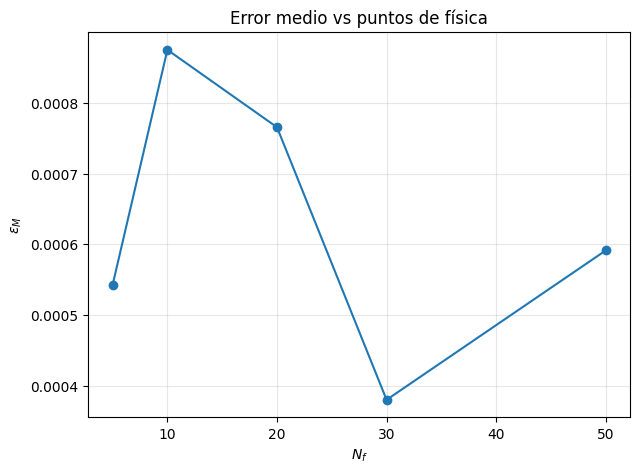

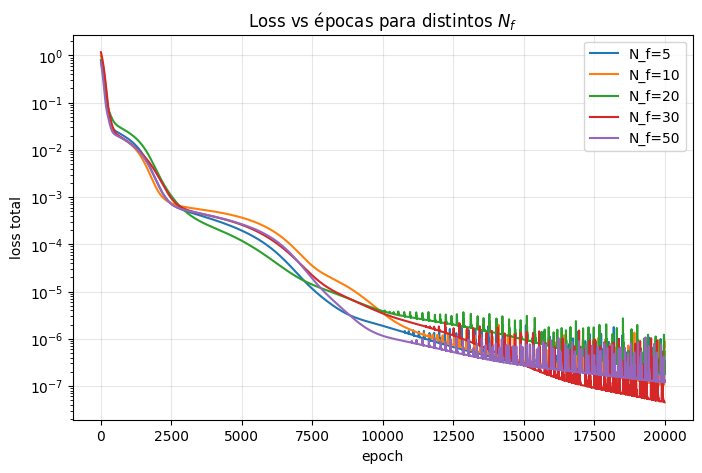

In [10]:
plt.figure(figsize=(7,5))
plt.plot(Nf_values, errors_mean_f, 'o-')
plt.xlabel(r'$N_f$')
plt.ylabel(r'$\epsilon_M$')
plt.title('Error medio vs puntos de física')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))

for Nf in Nf_values:
    plt.plot(loss_histories_f[Nf], label=f'N_f={Nf}')

plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss total')
plt.title('Loss vs épocas para distintos $N_f$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Punto v)

En este inciso se analizó la influencia del parámetro $\lambda$ en el entrenamiento de la PINN, manteniendo fijos $N_d = 10$ y $N_f = 20$. Se consideraron valores de $\lambda$ distribuidos logarítmicamente en el intervalo $[10^{-6},10^{-1}]$.

Se evaluó el error medio
$\epsilon_M = \left\langle \left\| \mathbf{X}_{\mathrm{PINN}}(t_n) - \mathbf{X}(t_n) \right\| \right\rangle$
junto con los valores finales de las pérdidas de datos y física.




In [ ]:
lambda_values = np.logspace(-6, -1, 6)
loss_data_final = []
loss_phys_final = []
errors_mean_lambda = []
loss_histories_lambda = {}

Nd = 10
Nf = 20

# ====================== DATOS FIJOS ======================
idx = np.linspace(0, len(t_full)-1, Nd, dtype=int)
t_data = torch.tensor(t_full[idx][:,None], dtype=torch.float32)
X_data = torch.tensor(X_full[idx], dtype=torch.float32)

t_phys = torch.linspace(t0, T, Nf).reshape(-1,1)

# ====================== LOOP ======================
for lam in lambda_values:

    model = PINN()

    model.train_pinn(
        t_data,
        X_data,
        t_phys,
        f_func=f_vec_torch,
        lambda_phys=lam,
        epochs=20000,
        lr=1e-4,
        print_every=20000
    )

    # guardar loss total
    loss_histories_lambda[lam] = model.loss_history.copy()

    # pérdidas finales
    loss_data_final.append(model.loss_data_history[-1])
    loss_phys_final.append(model.loss_physics_history[-1])

    # error medio
    with torch.no_grad():
        t_eval = torch.tensor(t_full[:,None], dtype=torch.float32)
        X_pred = model.forward(t_eval).numpy()

    error = np.linalg.norm(X_pred - X_full, axis=1)
    errors_mean_lambda.append(np.mean(error))

    print(f"lambda={lam:.1e} -> error={errors_mean_lambda[-1]:.3e}")


Epoch     0 | Total: 8.74e-01 | Data: 8.74e-01 | Physics: 3.71e+00
Entrenamiento completado.

lambda=1.0e-06 -> error=7.131e-04
Epoch     0 | Total: 7.97e-01 | Data: 7.97e-01 | Physics: 4.34e+00
Entrenamiento completado.

lambda=1.0e-05 -> error=3.598e-04
Epoch     0 | Total: 7.28e-01 | Data: 7.26e-01 | Physics: 1.49e+01
Entrenamiento completado.

lambda=1.0e-04 -> error=9.248e-04
Epoch     0 | Total: 9.95e-01 | Data: 9.80e-01 | Physics: 1.50e+01
Entrenamiento completado.

lambda=1.0e-03 -> error=7.521e-04
Epoch     0 | Total: 8.55e-01 | Data: 7.87e-01 | Physics: 6.79e+00
Entrenamiento completado.

lambda=1.0e-02 -> error=3.110e-04
Epoch     0 | Total: 2.04e+00 | Data: 7.77e-01 | Physics: 1.26e+01
Entrenamiento completado.

lambda=1.0e-01 -> error=1.351e-03


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\User\AppData\Local\Temp\ipykernel_22344\325251842.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Error medio vs $\lambda$')


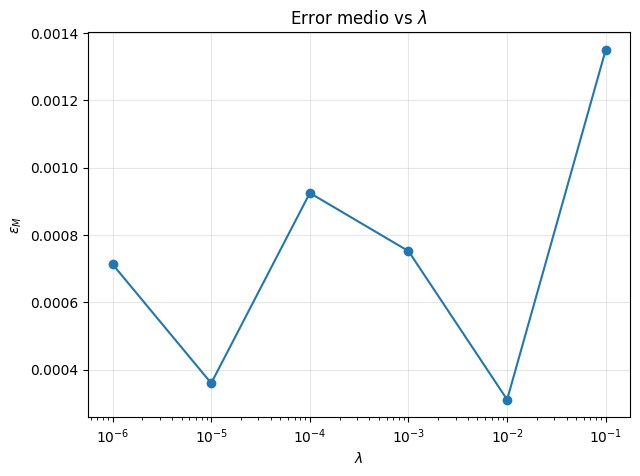

In [ ]:
plt.figure(figsize=(7,5))
plt.semilogx(lambda_values, errors_mean_lambda, 'o-')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\epsilon_M$')
plt.title('Error medio vs $\lambda$')
plt.grid(True, alpha=0.3)
plt.show()

Consideramos este resultado bastante interesante, podemos apreciar que $\lambda$ juega un papel crucial para tener un resultado coherente. Ya sabemos que $\lambda$ es un numerito que dice controla "el poder" de la perdida relativa entre el error fisico y el error de los datos, si $\lambda$ es muy chico entonces la funcion de perdida total es igual a la funcion de perdida de datos. Sabemos que la funcion error total se define como $$
\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda \, \mathcal{L}_{\text{phys}}
$$ Entonces si $\lambda\ll1$ podemos aproximar $\mathcal{L} \approx \mathcal{L}_{\text{data}}$ Por lo tanto, la red buscara unicamente unir los datos de forma grafica violando toda ley física. Por otro lado, si  $1\ll\lambda$ entonces podemos aproximar $\mathcal{L} \approx\mathcal{L}_{\text{phys}}$ conduciendo a graficas de soluciones triviales o donde se violen las condiciones de controno.

Encontramos un punto medio donde se consderan los 2 ajustes, en el mínimo del error medio exactamente en $\lambda=10^{-2}$ lo consideramos como el punto óptimo de lamda para estas circunstancias.



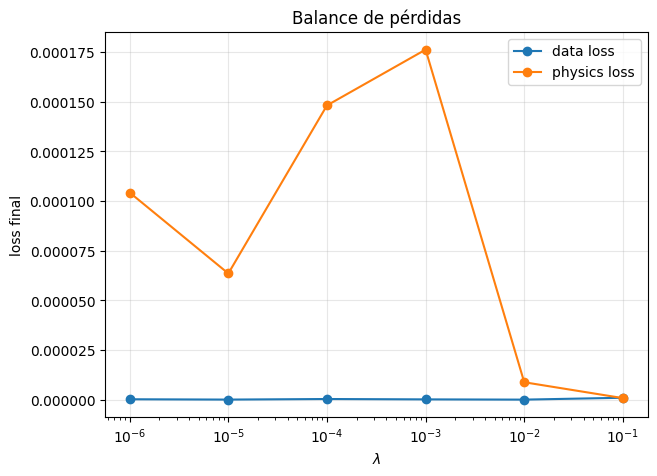

In [ ]:
plt.figure(figsize=(7,5))

plt.semilogx(lambda_values, loss_data_final, 'o-', label='data loss')
plt.semilogx(lambda_values, loss_phys_final, 'o-', label='physics loss')

plt.xlabel(r'$\lambda$')
plt.ylabel('loss final')
plt.title('Balance de pérdidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

para confirmar este $\lambda$ óptimo procedemos a graficar para distintos valores. Se puede apreciar que el valor antes mencionado el que menor error produce historicamente.

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\User\AppData\Local\Temp\ipykernel_22344\1989089055.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Loss vs épocas para distintos $\lambda$')


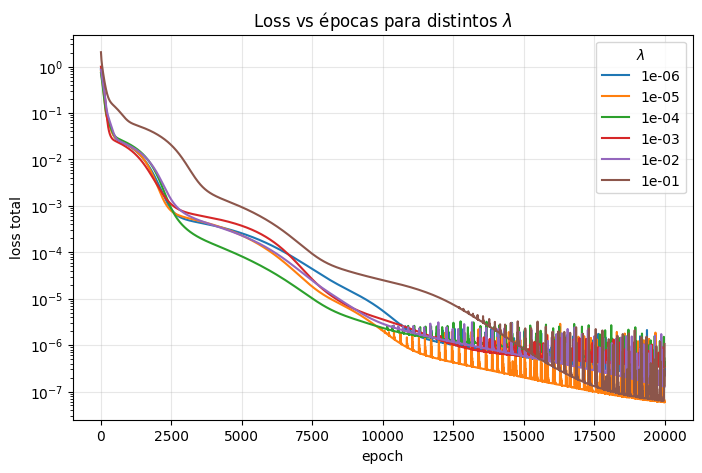

In [ ]:
plt.figure(figsize=(8,5))

for lam in lambda_values:
    plt.plot(loss_histories_lambda[lam], label=f'{lam:.0e}')

plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss total')
plt.title('Loss vs épocas para distintos $\lambda$')
plt.legend(title=r'$\lambda$')
plt.grid(True, alpha=0.3)
plt.show()

## Punto vi)

Para inciso vamos a probar 5 arquitecturas distitntas:

1.   2 capas con 16 neuronas c/u

2.   2 capas con 36 neuronas c/u

3.   2 capas con 64 neuronas c/u

4.   3 capas con 32 neuronas c/u

5.   3 capas con 64 neuronas c/u


fijaron los valores $N_d = 10$, $N_f = 20$ y $\lambda = 10^{-4}$, evaluaremos el desempeño en cada caso.



In [ ]:
Nd = 10
Nf = 20
lambda_phys = 1e-4

architectures = [
    [16,16],
    [32,32],
    [64,64],
    [32,32,32],
    [64,64,64]
]

arch_results = {}
arch_losses = {}

# datos fijos
idx = np.linspace(0, len(t_full)-1, Nd, dtype=int)
t_data = torch.tensor(t_full[idx][:,None], dtype=torch.float32)
X_data = torch.tensor(X_full[idx], dtype=torch.float32)

t_phys = torch.linspace(t0, T, Nf).reshape(-1,1)

for arch in architectures:

    print(f"\nArquitectura: {arch}")

    model = PINN(hidden_sizes=arch)

    model.train_pinn(
        t_data,
        X_data,
        t_phys,
        f_func=f_vec_torch,
        lambda_phys=lambda_phys,
        epochs=20000,
        lr=1e-4,
        print_every=20000
    )

    # guardar loss
    arch_losses[str(arch)] = model.loss_history.copy()

    # error medio
    with torch.no_grad():
        t_eval = torch.tensor(t_full[:,None], dtype=torch.float32)
        X_pred = model.forward(t_eval).numpy()

    error = np.linalg.norm(X_pred - X_full, axis=1)
    arch_results[str(arch)] = np.mean(error)

    print(f"Error medio: {arch_results[str(arch)]:.3e}")


Arquitectura: [16, 16]
Epoch     0 | Total: 1.24e+00 | Data: 1.24e+00 | Physics: 1.30e+01
Entrenamiento completado.

Error medio: 1.534e-03

Arquitectura: [32, 32]
Epoch     0 | Total: 1.32e+00 | Data: 1.31e+00 | Physics: 1.10e+01
Entrenamiento completado.

Error medio: 6.182e-04

Arquitectura: [64, 64]
Epoch     0 | Total: 1.22e+00 | Data: 1.22e+00 | Physics: 1.01e+01
Entrenamiento completado.

Error medio: 4.391e-04

Arquitectura: [32, 32, 32]
Epoch     0 | Total: 9.85e-01 | Data: 9.84e-01 | Physics: 1.64e+01
Entrenamiento completado.

Error medio: 6.760e-04

Arquitectura: [64, 64, 64]
Epoch     0 | Total: 9.17e-01 | Data: 9.13e-01 | Physics: 4.01e+01
Entrenamiento completado.

Error medio: 4.938e-04


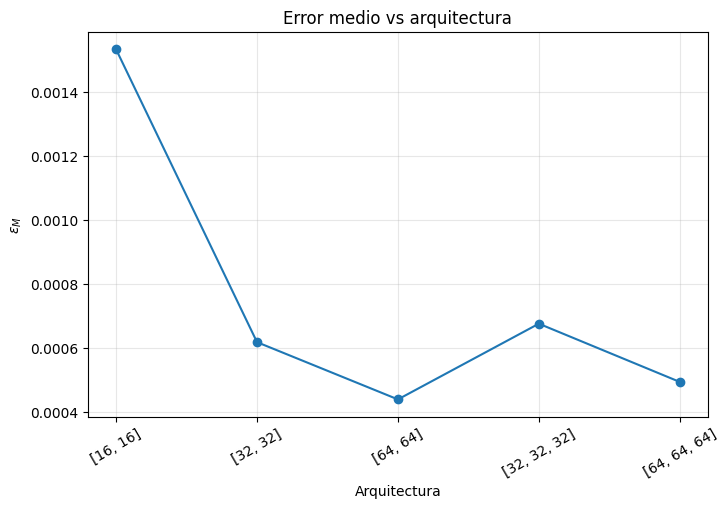

In [ ]:
labels = list(arch_results.keys())
values = list(arch_results.values())

plt.figure(figsize=(8,5))
plt.plot(labels, values, 'o-')
plt.xlabel('Arquitectura')
plt.ylabel(r'$\epsilon_M$')
plt.title('Error medio vs arquitectura')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.show()

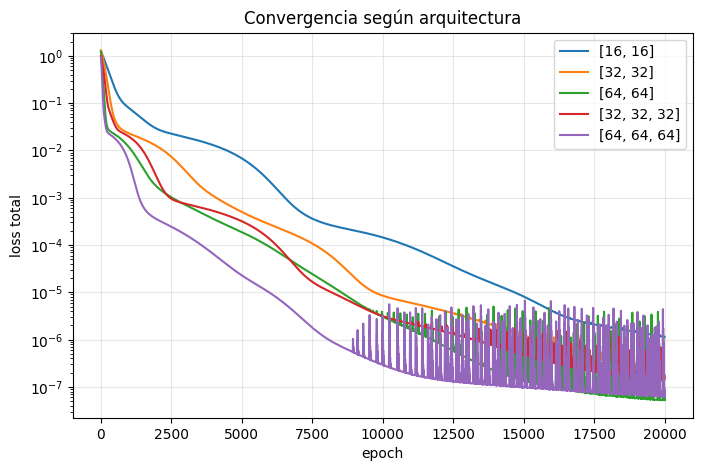

In [ ]:
plt.figure(figsize=(8,5))

for arch in arch_losses:
    plt.plot(arch_losses[arch], label=arch)

plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss total')
plt.title('Convergencia según arquitectura')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Para entender mejor estos comportameitnos primeros analizamos los casos limite. Parta una arquitectura de [16;16] podemos ver que su desenso no es tan pronunciado como los demas, tambien podemos apreciar un estancamiento y una convergencia prematura hacia ordenes de error de $10^{-6}$.

Por otro lado tenemos un sistema de forma [64;64;64], podemos apreciar que decrece mucho mas rapidamente que sus anteriores modelos, tambien observamos una cinvergencia de errores de valores por debajo de un orden de magnitud de $10^{-7}$ teniendo una mayor presición, sin embargo esta arquitectura es donde el fenómeno de "gradiente explosivo" es mas notable. Esto se puede atribuir a que la propagacion de errores es mucho mayor en aquellos sistemas con mas capas mas densas.

Tomando esta informacion concluimos que la mejor arquitectura será un balance entre estos dos extremos, graficamente podemos elegir us sistema tipo [64;64] o [32;32:32]